In [1]:
import io
import os
import zipfile
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Configure aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)

# Download MovieLens Small dataset automatically
dataset_url = "https://files.grouplens.org/datasets/movielens/ml-latest-small.zip"
data_dir = "ml-latest-small"

if not os.path.exists(data_dir):
    print("Downloading MovieLens dataset...")
    r = requests.get(dataset_url)
    z = zipfile.ZipFile(io.BytesIO(r.content))
    z.extractall()
    print("Download and extraction complete!")
else:
    print("Dataset directory already exists.")

# Load movies and ratings data
movies_df = pd.read_csv(f"{data_dir}/movies.csv")
ratings_df = pd.read_csv(f"{data_dir}/ratings.csv")

print(f"Total Movies: {movies_df.shape[0]:,}")
print(f"Total Ratings: {ratings_df.shape[0]:,}")
display(movies_df.head(3))
display(ratings_df.head(3))

Matplotlib is building the font cache; this may take a moment.


Download and extraction complete!
Total Movies: 9,742
Total Ratings: 100,836


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224


C:\Users\USER\AppData\Local\Temp\ipykernel_13476\2674741727.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=ratings_df, x="rating", palette="Blues_r", ax=ax[0])
C:\Users\USER\AppData\Local\Temp\ipykernel_13476\2674741727.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_movies, y='title', x='rating_count', palette="viridis", ax=ax[1])


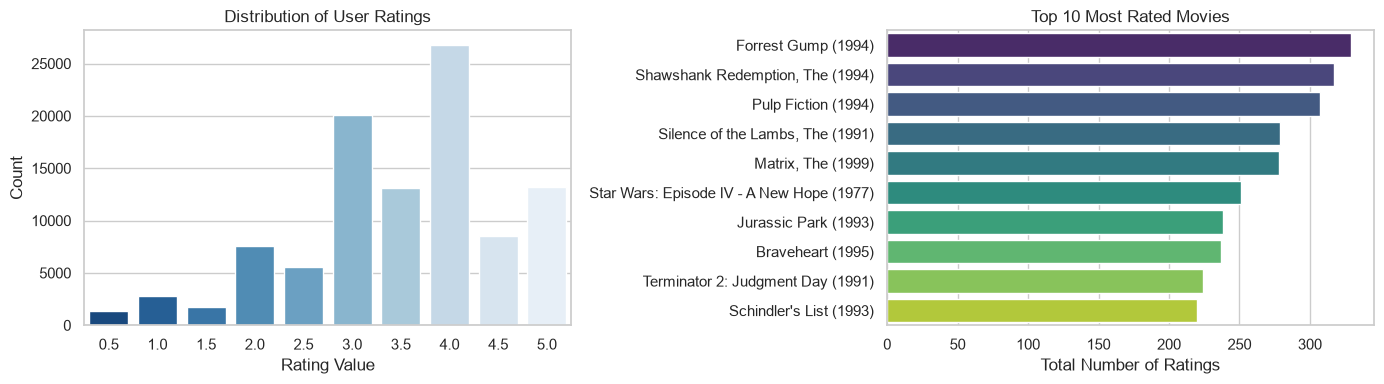

Users: 610 | Movies rated: 9724
Matrix Sparsity: 98.30% (sparse interaction matrix)


In [2]:
# 1. Rating value distribution
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

sns.countplot(data=ratings_df, x="rating", palette="Blues_r", ax=ax[0])
ax[0].set_title("Distribution of User Ratings")
ax[0].set_xlabel("Rating Value")
ax[0].set_ylabel("Count")

# 2. Top 10 most rated movies
top_rated_ids = ratings_df['movieId'].value_counts().head(10).reset_index()
top_rated_ids.columns = ['movieId', 'rating_count']
top_movies = top_rated_ids.merge(movies_df, on='movieId')

sns.barplot(data=top_movies, y='title', x='rating_count', palette="viridis", ax=ax[1])
ax[1].set_title("Top 10 Most Rated Movies")
ax[1].set_xlabel("Total Number of Ratings")
ax[1].set_ylabel("")

plt.tight_layout()
plt.show()

# Sparsity calculation
n_users = ratings_df['userId'].nunique()
n_items = ratings_df['movieId'].nunique()
sparsity = 1.0 - (len(ratings_df) / (n_users * n_items))
print(f"Users: {n_users} | Movies rated: {n_items}")
print(f"Matrix Sparsity: {sparsity * 100:.2f}% (sparse interaction matrix)")

In [3]:
# Preprocess genres: replace '|' with spaces
movies_df['genres_processed'] = movies_df['genres'].fillna('').str.replace('|', ' ', regex=False)

# Compute TF-IDF matrix over genres
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(movies_df['genres_processed'])

# Pairwise cosine similarity matrix
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

# Recommendation function
def recommend_content(title, top_n=5):
    matches = movies_df[movies_df['title'].str.contains(title, case=False, na=False)]
    if matches.empty:
        return f"No title matching '{title}' found."
    
    idx = matches.index[0]
    matched_title = movies_df.iloc[idx]['title']
    
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    
    top_indices = [i[0] for i in sim_scores[1:top_n + 1]]
    scores = [round(i[1], 3) for i in sim_scores[1:top_n + 1]]
    
    results = movies_df.iloc[top_indices][['title', 'genres']].copy()
    results['similarity_score'] = scores
    
    print(f"Top {top_n} recommendations based on '{matched_title}':")
    return results

# Test recommendation
recommend_content("Toy Story", top_n=5)

Top 5 recommendations based on 'Toy Story (1995)':


,title,genres,similarity_score
1706,Antz (1998),Adventure|Animation|Children|Comedy|Fantasy,1.0
2355,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy,1.0
2809,"Adventures of Rocky and Bullwinkle, The (2000)",Adventure|Animation|Children|Comedy|Fantasy,1.0
3000,"Emperor's New Groove, The (2000)",Adventure|Animation|Children|Comedy|Fantasy,1.0
3568,"Monsters, Inc. (2001)",Adventure|Animation|Children|Comedy|Fantasy,1.0


In [4]:
# Create User-Item Pivot Matrix
pivot_df = ratings_df.pivot(index='userId', columns='movieId', values='rating').fillna(0)

# Normalize ratings by de-meaning (subtract user average on rated movies)
user_ratings = pivot_df.values
user_mean = np.true_divide(user_ratings.sum(1), (user_ratings != 0).sum(1))
user_ratings_demeaned = np.where(user_ratings != 0, user_ratings - user_mean[:, np.newaxis], 0)

# Apply TruncatedSVD (Latent Factor Model)
n_latent_factors = 20
svd = TruncatedSVD(n_components=n_latent_factors, random_state=42)
latent_user_matrix = svd.fit_transform(user_ratings_demeaned)

# Reconstruct rating predictions
predicted_demeaned = svd.inverse_transform(latent_user_matrix)
predicted_ratings = predicted_demeaned + user_mean[:, np.newaxis]

pred_matrix_df = pd.DataFrame(predicted_ratings, index=pivot_df.index, columns=pivot_df.columns)
print("SVD Matrix Factorization trained successfully!")

SVD Matrix Factorization trained successfully!


In [5]:
actual_ratings = []
predicted_values = []

# Sample observed ratings for testing reconstruction accuracy
sample_ratings = ratings_df.sample(n=min(10000, len(ratings_df)), random_state=42)

for _, row in sample_ratings.iterrows():
    u = int(row['userId'])
    m = int(row['movieId'])
    actual = row['rating']
    if u in pred_matrix_df.index and m in pred_matrix_df.columns:
        pred = pred_matrix_df.loc[u, m]
        actual_ratings.append(actual)
        predicted_values.append(np.clip(pred, 0.5, 5.0))

rmse = np.sqrt(mean_squared_error(actual_ratings, predicted_values))
mae = mean_absolute_error(actual_ratings, predicted_values)

print(f"--- Model Evaluation (Collaborative Filtering SVD) ---")
print(f"RMSE (Root Mean Squared Error): {rmse:.4f}")
print(f"MAE  (Mean Absolute Error)     : {mae:.4f}")

--- Model Evaluation (Collaborative Filtering SVD) ---
RMSE (Root Mean Squared Error): 0.7625
MAE  (Mean Absolute Error)     : 0.5359


In [6]:
def recommend_for_user(user_id, top_n=5):
    if user_id not in pivot_df.index:
        return f"User ID {user_id} not found."
    
    user_actual = pivot_df.loc[user_id]
    user_predictions = pred_matrix_df.loc[user_id]
    
    # Filter only unrated items (where actual rating is 0)
    unrated_mask = (user_actual == 0)
    unrated_predictions = user_predictions[unrated_mask]
    
    top_movie_ids = unrated_predictions.sort_values(ascending=False).head(top_n).index
    predicted_scores = unrated_predictions.loc[top_movie_ids].values
    
    recs = movies_df[movies_df['movieId'].isin(top_movie_ids)][['movieId', 'title', 'genres']].copy()
    recs['predicted_rating'] = [round(score, 2) for score in predicted_scores]
    return recs

print("Personalized recommendations for User ID 1:")
recommend_for_user(user_id=1, top_n=5)

Personalized recommendations for User ID 1:


,movieId,title,genres,predicted_rating
31,32,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),Mystery|Sci-Fi|Thriller,4.66
277,318,"Shawshank Redemption, The (1994)",Crime|Drama,4.65
474,541,Blade Runner (1982),Action|Sci-Fi|Thriller,4.59
613,778,Trainspotting (1996),Comedy|Crime|Drama,4.56
659,858,"Godfather, The (1972)",Crime|Drama,4.56
